# Klasifikacija ćelija cervikalnog karcinoma primenom transfer learning pristupa

Ovaj notebook prikayuje kompletan eksperimentalni tok za multiklasnu klasifikaciju ćelija iz skupa podataka Cervical Cancer (SIPaKMeD) korišćenjem konvolucionih neurnonskih mreža i transfer learning pristupa. Ova klasifikacija je ynačajna zbog toga što se radi o analizi ćelija sa Papa testa, a cilj je da se automatski prepoznaju normalne, abnormalne i sumnjive promene na ćelijama grlića materice.

## 1. Instalacija i import biblioteka

U ovom delu se priprema radno okruženje.

In [1]:
import os
from collections import Counter
import pandas as pd
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0, EfficientNetB4, ResNet50
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import seaborn as sns
from sklearn.metrics import confusion_matrix

2026-04-08 21:32:53.758862: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775683974.304004      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775683974.440461      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775683975.506101      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775683975.506143      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775683975.506146      24 computation_placer.cc:177] computation placer alr

## 2. Preuzimanje skupa podataka

Ovde se preuzima **SIPaKMeD / Cervical Cancer dataset** sa Kaggle platforme. Cilj je da se obezbedi automatsko i dosledno preuzimanje podataka bez ručnog kopiranja fajlova.

In [2]:
path = "/kaggle/input/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed"

## 3. Formiranje liste slika i pripadajućih klasa

U ovom koraku prolazimo kroz foldere koji odgovaraju klasama i izdvajamo putanje do slika iz "CROPPED" direktorijuma.

Zašto se koriste **CROPPED** slike?
Pošto su ćelije već izdvojene iz šire mikroskopske scene, model se fokusira na morfološke karakteristike same ćelije, a ne na pozadinu. To je posebno važno kod medicinskih slika, jer smanjuje šum i omogućava stabilnije učenje.

Klase u eksperimentu:
  * im_Dyskeratotic
  * im_Koilocytotic
  * im_Metaplastic
  * im_Parabasal
  * im_Superficial-Intermediate

S obzirom da ne znam puno o medicini, istražio sam šta bi ukratko bile razlike između ovih klasa.

Ove klase nisu iste "težine" u medicinskom smislu. U literaturi SIPaKMeD se navodi:
  * Superficial-Intermediate i Parabasal kao normalne ćelije
  * Koilocytotic i Dyskeratotic kao abnormalne ćelije
  * Metaplastic kao benigna, ali sumnjiva (potencijalno pre kancerozna) promena, pa je zato interesantna za klasifikaciju.

In [3]:
cropped_bmp_files = []

class_folders = [
    "im_Dyskeratotic",
    "im_Koilocytotic",
    "im_Metaplastic",
    "im_Parabasal",
    "im_Superficial-Intermediate"
]

# Struktura foldera je sledeća - root/im_Parabasal/im_Parabasal
# U svakom folderu postoje originalne (velike) slike, i croppovane slike.
# Kropovane slike sadrže samo jednu ćeliju, dok originalne slike sadrže ceo uzorak
for class_name in class_folders:
    cropped_dir = os.path.join(path, class_name, class_name, "CROPPED")

    # U folderu nisu samo slike, već postoje i neki .dat fajlovi, koji se ne mogu učitati
    # Zato ovde uzimamo samo one koji imaju ekstenziju .bmp
    for file_name in os.listdir(cropped_dir):
        if file_name.lower().endswith(".bmp"):
            file_path = os.path.join(cropped_dir, file_name)
            cropped_bmp_files.append((class_name, file_path))

class_counts = Counter(label for label, _ in cropped_bmp_files)

print("Ukupno cropped BMP slika:", len(cropped_bmp_files))
print(class_counts)

Ukupno cropped BMP slika: 4049
Counter({'im_Superficial-Intermediate': 831, 'im_Koilocytotic': 825, 'im_Dyskeratotic': 813, 'im_Metaplastic': 793, 'im_Parabasal': 787})


## 4. Kreiranje tabelarnog prikaza podataka

Ovde se lista putanja i labela pretvara u DataFrame. Na ovaj način je obezbeđena pregledna organizacija podataka i olakšana dalja podela na trening, validacioni i test skup.

In [4]:
df = pd.DataFrame(cropped_bmp_files, columns=["label", "filepath"])

print(df.head())
print()
print("Ukupno redova:", len(df))
print()
print(df["label"].value_counts())

             label                                           filepath
0  im_Dyskeratotic  /kaggle/input/datasets/prahladmehandiratta/cer...
1  im_Dyskeratotic  /kaggle/input/datasets/prahladmehandiratta/cer...
2  im_Dyskeratotic  /kaggle/input/datasets/prahladmehandiratta/cer...
3  im_Dyskeratotic  /kaggle/input/datasets/prahladmehandiratta/cer...
4  im_Dyskeratotic  /kaggle/input/datasets/prahladmehandiratta/cer...

Ukupno redova: 4049

label
im_Superficial-Intermediate    831
im_Koilocytotic                825
im_Dyskeratotic                813
im_Metaplastic                 793
im_Parabasal                   787
Name: count, dtype: int64


## 5. Podela podataka na train, validation i test skup

Podaci se dele u tri dela:
  * **train** - skup za učenje modela ~ 80%
  * **validation** - skup za praćenje generalizacije tokom treniranja ~ 10%
  * **test** - skup za konačnu procenu performansi ~10%

  Koristi se stratifikovana podela (stratify) kako bi odnos klasa ostao približno isti u svim skupovima. To je veoma važna praksa kod klasifikacije medicinskih slika, jer smanjuje rizik da neka klasa bude nedovoljno zastupljena u jednom od podskupova.

In [5]:
train_df, test_df = train_test_split(df, test_size=0.1, stratify=df["label"], random_state=42)

In [6]:
train_df, val_df = train_test_split(train_df, test_size=0.1111, stratify=train_df["label"], random_state=42)

### 5.1. Provera raspodele po skupovima

Nakon podele, potrebno je proveriti:
  * Ukupan broj uzoraka po skupu
  * Raspodelu klasa unutar svakog skupa

Ovaj korak je sproveden kako bi se potvrdilo da je stratifikovana podela uspešno očuvala reprezentativnost svih klasa u svakom podskupu.

In [7]:
print(f"Trening skup: {len(train_df)}")
print(f"Validacioni skup: {len(val_df)}")
print(f"Test skup: {len(test_df)}")

print(f"\nTrening distribucija:\n{train_df["label"].value_counts()}")
print(f"\nValidaciona distribucija:\n{val_df["label"].value_counts()}")
print(f"\nTest distribucija:\n{test_df["label"].value_counts()}")

Trening skup: 3239
Validacioni skup: 405
Test skup: 405

Trening distribucija:
label
im_Superficial-Intermediate    665
im_Koilocytotic                659
im_Dyskeratotic                651
im_Metaplastic                 635
im_Parabasal                   629
Name: count, dtype: int64

Validaciona distribucija:
label
im_Koilocytotic                83
im_Superficial-Intermediate    83
im_Dyskeratotic                81
im_Parabasal                   79
im_Metaplastic                 79
Name: count, dtype: int64

Test distribucija:
label
im_Koilocytotic                83
im_Superficial-Intermediate    83
im_Dyskeratotic                81
im_Metaplastic                 79
im_Parabasal                   79
Name: count, dtype: int64


## 6. Definisanje dimenzije slike, batch veličine i augmentacije


### Dimenzija slike:
Ulazna dimenzija slike je postavljena na 224x224, što odgovara standardnom ulazu za `EfficientNetB0`.

### Batch veličina
`BATCH_SIZE = 32` predstavlja dobar kompromis između brzine treniranja i potrošnje memorije.‚

### Augmentacija
Na trening skupu se primenjuju blage transformacije:
  * rotacija
  * horizontalno i vertikalno pomeranje
  * zumiranje
  * horizontalno preslikavanje

Cilj augmentacije je da model vidi više varijacija istih klasa i da manje overfituje.
Validacioni i test skup ne prolaze augmentaciju, jer treba da predstavljaju realne neizmenjene podatke.



In [8]:
IMG_SIZE = (224, 224) # Za EfficientNetB0, EfficientNetB4, ResNet50
BATCH_SIZE = 32 # Standardan izbor

# Augmentacija
train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator() # Za validacione i test podatke se ne radi augmentacija

## 7. Kreiranje generatora za učitavanje slika

`flow_from_dataframe` omogućava da se slike učitavaju direktno sa putanja navedenih u `DataFrame` tabelama.

### Prednosti generatora
  * Ne učitava ceo skup odmah u memoriju
  * Omogućava batch obradu
  * Može da kombinuje augmentaciju i labeliranje
  * Praktičan je za rad sa većim skupovima slika

Za trening generator se koristi `shuffle=True` dok se za validation i test obično koristi stabilan redosled radi lakše evaluacije.


In [9]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 3239 validated image filenames belonging to 5 classes.
Found 405 validated image filenames belonging to 5 classes.
Found 405 validated image filenames belonging to 5 classes.


In [10]:
print(train_generator.class_indices)

{'im_Dyskeratotic': 0, 'im_Koilocytotic': 1, 'im_Metaplastic': 2, 'im_Parabasal': 3, 'im_Superficial-Intermediate': 4}


## 8. Definisanje modela: Transfer Learning sa ResNet50

U ovom delu se koristi unapred istrenirana arhitektura ResNet50 sa težinama naučenim na skupu ImageNet. U ranijim iteracijama ovog notebook-a, isprobani su i EfficientNetB0, EfficientNetB4, međutim empirijski se ispostavilo da ResNet50 za sada daje najbolji rezultat na test skupu.

S obzirom da je jako teško naći sličan skup podataka (i generalno medicinske skupove podataka), koji je dovoljno veliki za treniranje duboke mreže od nule, ovde se koristi model koji je već naučio opšte vizuelne obrasce, a zatim se prilagođava konkretnom zadatku.

Postavljanjem `base_model.trainable = False` zadržava se već naučeno, a treniraju se samo završni slojevi za novu klasifikaciju. To smanjuje rizik od overfitting-a i ubrzava trening.

In [11]:
num_classes = len(train_generator.class_indices)

#base_model = EfficientNetB0( # Transfer Learning
#    weights="imagenet",
#    include_top=False, # Ne uzimamo zavrsni sloj
#    input_shape=(224, 224, 3)
#)

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

#base_model = EfficientNetB4(
#    weights="imagenet",
#    include_top=False,
#    input_shape=(224, 224, 3)
#)

# Zamrzavamo model
base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))

x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.3)(x)

x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.2)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

model.summary()

I0000 00:00:1775684029.035691      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775684029.041806      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,779,653 (94.53 MB)

 Trainable params: 1,186,821 (4.53 MB)

 Non-trainable params: 23,592,832 (90.00 MB)

## 9. Kompajliranje modela

Model se kompajlira korišćenjem:
  * optimizatora AdamW,
  * gubitka Categorical Crossentropy
  * metrike accuracy

In [12]:
optimizer = tf.keras.optimizers.AdamW(learning_rate=1e-4)

loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=["accuracy"]
)

## 10. Callback mehanizmi tokom treniranja

Tokom treniranja koriste se tri važna callback-a:
  * **Early stopping** - prekida trening kada validation performanse prestanu da se poboljšavaju
  * **ModelCheckpoint** - čuva najbolju verziju modela
  * **ReduceLROnPlateau** - smanjuje learning rate kada napredak uspori

In [13]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    #"best_efficientnet_cervical.keras",
    #"best_efficientNetB4_cervical.keras",
    "best_resnet50_cervical.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

## 11. Treniranje modela

U ovom koraku, model prolazi kroz epohe i uči na trening skupu, dok se nakon svake epohe proverava ponašanje na validacionom skupu.

In [14]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1775684042.584333      73 service.cc:152] XLA service 0x78cecc002320 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775684042.584374      73 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775684042.584378      73 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775684044.814635      73 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/102 ━━━━━━━━━━━━━━━━━━━━ 29:23 17s/step - accuracy: 0.2812 - loss: 2.5559

I0000 00:00:1775684051.790523      73 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 630ms/step - accuracy: 0.5004 - loss: 1.5857
Epoch 1: val_loss improved from inf to 0.82906, saving model to best_resnet50_cervical.keras
102/102 ━━━━━━━━━━━━━━━━━━━━ 94s 758ms/step - accuracy: 0.5019 - loss: 1.5817 - val_accuracy: 0.8370 - val_loss: 0.8291 - learning_rate: 1.0000e-04
Epoch 2/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.8474 - loss: 0.7628
Epoch 2: val_loss improved from 0.82906 to 0.66918, saving model to best_resnet50_cervical.keras
102/102 ━━━━━━━━━━━━━━━━━━━━ 41s 400ms/step - accuracy: 0.8475 - loss: 0.7627 - val_accuracy: 0.8864 - val_loss: 0.6692 - learning_rate: 1.0000e-04
Epoch 3/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.8725 - loss: 0.6953
Epoch 3: val_loss improved from 0.66918 to 0.61718, saving model to best_resnet50_cervical.keras
102/102 ━━━━━━━━━━━━━━━━━━━━ 41s 403ms/step - accuracy: 0.8725 - loss: 0.6953 - val_accuracy: 0.9136 - val_loss: 0.6172 - learning_rate: 1.0000e-04
Epoch 4/50
102/1

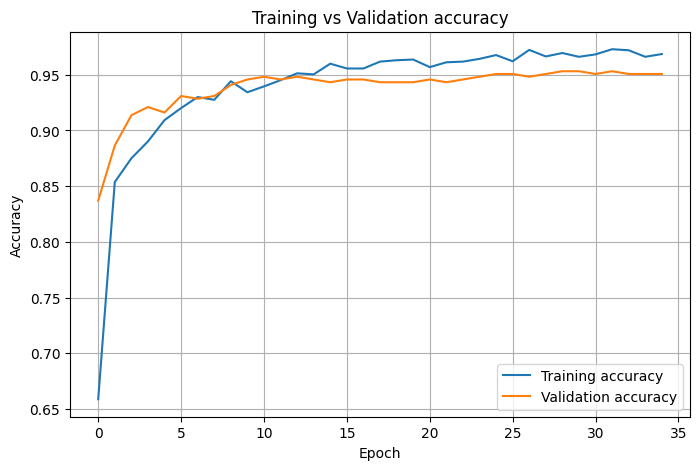

In [15]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label="Training accuracy")
plt.plot(history.history['val_accuracy'], label="Validation accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation accuracy")

plt.legend()
plt.grid()

plt.show()

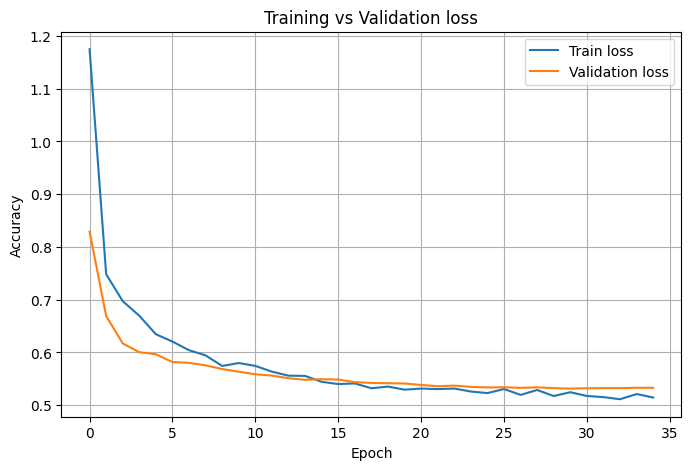

In [16]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label="Train loss")
plt.plot(history.history['val_loss'], label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation loss")

plt.legend()
plt.grid()

plt.show()

## 12. Evaluacija na test skupu

Nakon što je trening završen, model se procenjuje na test skupu, koji nije korišćen ni za učenje ni za izbor parametara.

In [17]:
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test loss: {test_loss}" )
print(f"Test accuracy: {test_accuracy}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 347ms/step - accuracy: 0.9606 - loss: 0.5427
Test loss: 0.5180686116218567
Test accuracy: 0.9679012298583984


## 13. Fina podešavanja

Nakon evaluacije na test skupu, u ovom poglavlju se fokusiramo na proces finog podešavanja (fine-tuning) putem odmrzavanja poslednjih slojeva baznog modela. Cilj ove procedure je adaptacija pretreniranih težina našeg skupa podataka kako bi se postigla viša preciznost klasifikacije.

In [18]:
# Fine tunning
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False


optimizer = tf.keras.optimizers.AdamW(learning_rate=1e-5, weight_decay=1e-4)

model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=["accuracy"]
)

checkpoint_finetune = ModelCheckpoint(
    "best_resnet50_finetuned_cervical.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=[early_stop, checkpoint_finetune, reduce_lr]
)

Epoch 1/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.9393 - loss: 0.5773
Epoch 1: val_loss improved from inf to 0.55156, saving model to best_resnet50_finetuned_cervical.keras
102/102 ━━━━━━━━━━━━━━━━━━━━ 73s 523ms/step - accuracy: 0.9392 - loss: 0.5773 - val_accuracy: 0.9506 - val_loss: 0.5516 - learning_rate: 1.0000e-05
Epoch 2/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.9457 - loss: 0.5598
Epoch 2: val_loss improved from 0.55156 to 0.54950, saving model to best_resnet50_finetuned_cervical.keras
102/102 ━━━━━━━━━━━━━━━━━━━━ 41s 398ms/step - accuracy: 0.9457 - loss: 0.5597 - val_accuracy: 0.9506 - val_loss: 0.5495 - learning_rate: 1.0000e-05
Epoch 3/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.9398 - loss: 0.5672
Epoch 3: val_loss improved from 0.54950 to 0.54433, saving model to best_resnet50_finetuned_cervical.keras
102/102 ━━━━━━━━━━━━━━━━━━━━ 42s 407ms/step - accuracy: 0.9398 - loss: 0.5672 - val_accuracy: 0.9481 - val_loss: 0.5443 - l

## 13. Evaluacija na test skupu nakon finih podešavanja

Nakon što je fine tuning trening završen, model se procenjuje opet test skupu, koji nije korišćen ni za učenje ni za izbor parametara.

In [19]:
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test loss after fine tunning: {test_loss}")
print(f"Test accuracy after fine tunning: {test_accuracy}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 0.9467 - loss: 0.5248
Test loss after fine tunning: 0.5087036490440369
Test accuracy after fine tunning: 0.9555555582046509


## 14. Matrica konfuzije

Nakon što je fine tuning trening završen, model se procenjuje opet test skupu, koji nije korišćen ni za učenje ni za izbor parametara.

In [20]:
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = test_generator.classes
cm = confusion_matrix(y_true, y_pred)

class_names = list(test_generator.class_indices.keys())


13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 412ms/step


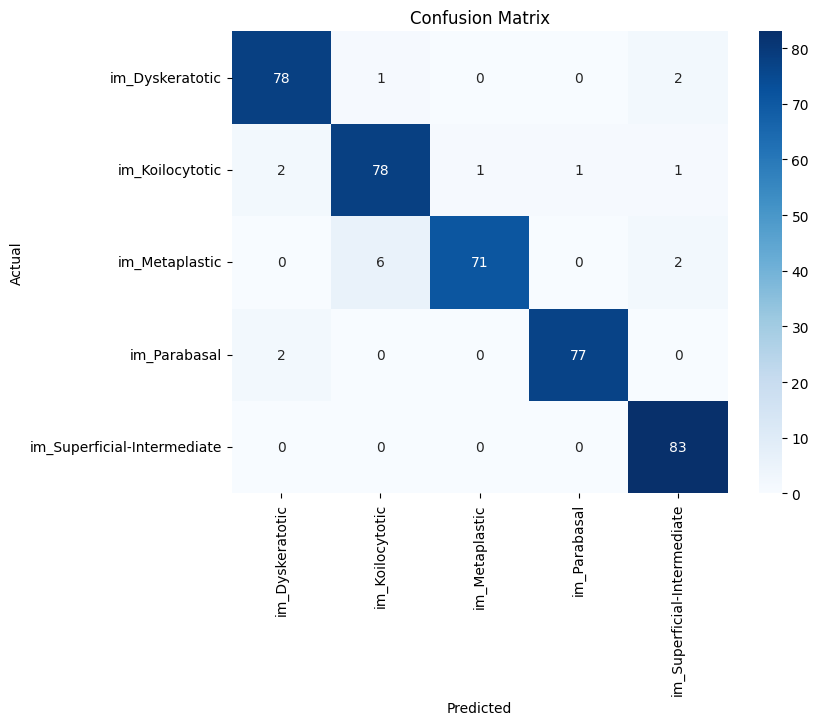

In [21]:
plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",xticklabels=class_names, yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [22]:
from IPython.display import FileLink
FileLink("best_resnet50_cervical.keras")

/kaggle/working/best_resnet50_cervical.keras

In [23]:
FileLink("best_resnet50_finetuned_cervical.keras")

/kaggle/working/best_resnet50_finetuned_cervical.keras